In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [ ]:
from src.dataset import prepare_dataset
from src.model import build_xception_model
from src.train import compile_model
from src.callbacks import get_callbacks

In [ ]:
(
    X_train,
    X_test,
    y_train,
    y_test,
    labels,
    encoder
) = prepare_dataset()

In [6]:
from src.model import build_xception_model
from src.train import compile_model

model = build_xception_model(
    input_shape=(224,224,3),
    num_classes=10
)

model = compile_model(model)

print(model)

<Functional name=functional, built=True>


In [8]:
from src.callbacks import get_callbacks

callbacks = get_callbacks()

print(callbacks)

[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x000001BC90261E80>, <keras.src.callbacks.model_checkpoint.ModelCheckpoint object at 0x000001BC90261FD0>]


In [9]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(
        X_test,
        y_test
    ),
    epochs=10,
    batch_size=16,
    callbacks=callbacks
)

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2077 - loss: 2.3228
Epoch 1: val_accuracy improved from None to 0.74850, saving model to ..\outputs\models\best_model.keras

Epoch 1: finished saving model to ..\outputs\models\best_model.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 161s 4s/step - accuracy: 0.3218 - loss: 2.0957 - val_accuracy: 0.7485 - val_loss: 1.5392
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6137 - loss: 1.4605
Epoch 2: val_accuracy improved from 0.74850 to 0.89222, saving model to ..\outputs\models\best_model.keras

Epoch 2: finished saving model to ..\outputs\models\best_model.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 217s 4s/step - accuracy: 0.6827 - loss: 1.3090 - val_accuracy: 0.8922 - val_loss: 0.9243
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8100 - loss: 0.9172
Epoch 3: val_accuracy improved from 0.89222 to 0.96407, saving model to ..\outputs\models\best_model.keras

Epoch 3: finished saving model to ..\outputs\models\best_mod

In [11]:
from src.visualization import (
    plot_training_history,
    plot_loss_history
)

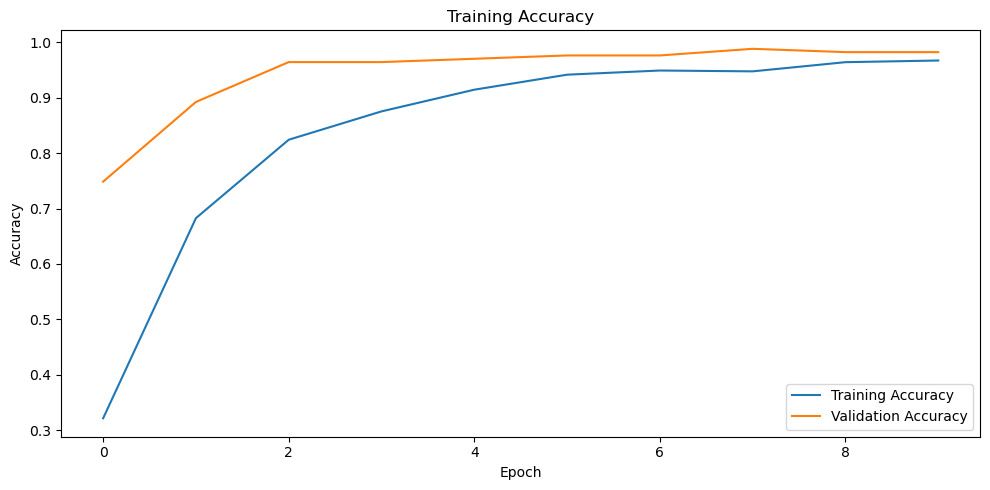

In [12]:
plot_training_history(history)

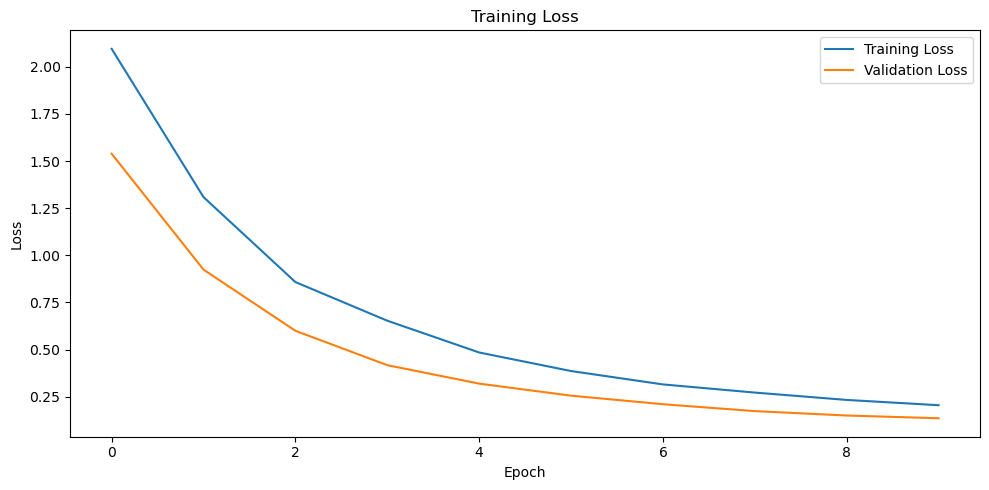

In [13]:
plot_loss_history(history)

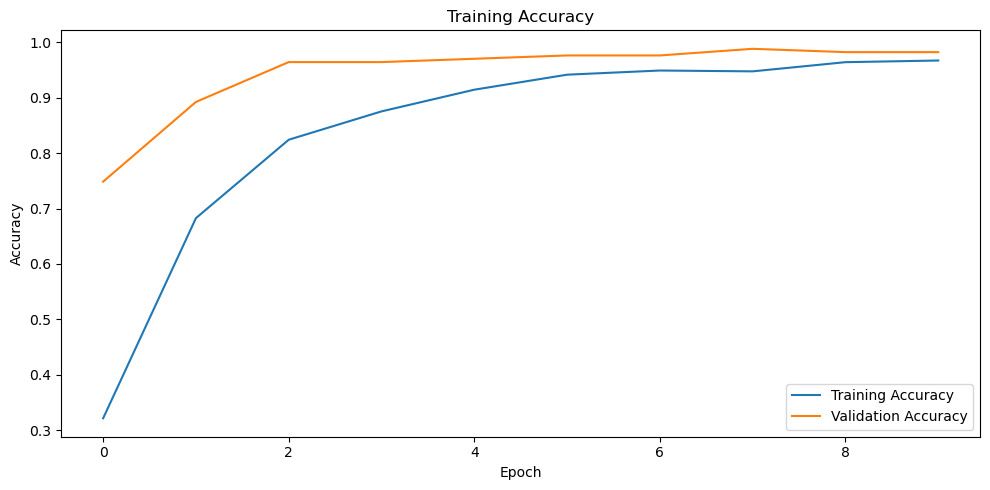

<Figure size 640x480 with 0 Axes>

In [14]:
import matplotlib.pyplot as plt

plot_training_history(history)

plt.savefig(
    "../outputs/figures/training_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

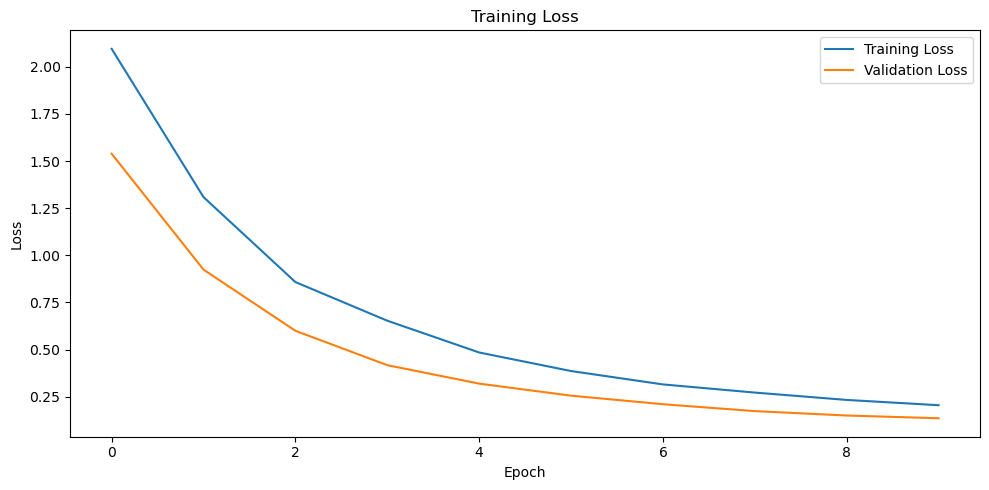

<Figure size 640x480 with 0 Axes>

In [15]:
plot_loss_history(history)

plt.savefig(
    "../outputs/figures/training_loss.png",
    dpi=300,
    bbox_inches="tight"
)